In [ ]:
import sys
import os
import shutil
from pathlib import Path

# 1. Create the expected directory structure in Kaggle's working folder
base_dir = Path("/kaggle/working/dummtdatasets/cashflow")
base_dir.mkdir(parents=True, exist_ok=True)
(Path("/kaggle/working/dummtdatasets") / "__init__.py").touch(exist_ok=True)
(base_dir / "__init__.py").touch(exist_ok=True)

# 2. Search Kaggle input folder for the uploaded scripts
input_dir = Path("/kaggle/input")
if input_dir.exists():
    for py_file in input_dir.rglob("*.py"):
        if py_file.name in ["multihead_generate_nabard.py", "nabard_cashflow_utils.py"]:
            shutil.copy2(py_file, base_dir / py_file.name)
            print(f"Copied {py_file.name} to {base_dir}")

# 3. Add the working directory to the Python path
if "/kaggle/working" not in sys.path:
    sys.path.insert(0, "/kaggle/working")
    print("✅ Files copied and path configured!")



# GramPulse — NABARD Rural-Enterprise Cashflow TFT Pipeline

This notebook converts the earlier personal-finance experiment into a **privacy-preserving rural-enterprise forecasting and early-warning pipeline**.

### Implemented
- Rural sectors: Dairy, Poultry, Food Processing and Rural Retail
- Enterprise types: Individual, Micro Enterprise, SHG and FPO
- Financial, aggregate UPI, market, climate and credit features
- Targets: `operating_inflow`, `operating_outflow`, `closing_cash_balance`
- Strict 24/6/6 chronological split
- Seasonal-naive, moving-average and CatBoost baselines
- Multi-target probabilistic Temporal Fusion Transformer
- Untouched six-month test evaluation
- Deterministic early-warning JSON for the GramPulse dashboard

### Deliberate exclusions
The XGBoost residual layer is removed. FinePhrase remains a downstream explanation service and is not part of numeric model training.

## Implementation decisions

The uploaded notebook references `multihead_generate.py`, but that generator was not included with the notebook. This bundle therefore provides a **new drop-in generator**: `multihead_generate_nabard.py` (also copied as `multihead_generate.py` for compatibility).

CatBoost is embedded in this notebook so every model is trained and evaluated against the same chronological split. External climate and market variables in the decoder are explicitly named `forecast_*` or `*_scenario`; they represent information that would be available from a forecast/scenario service at inference time, rather than leaked future actuals.

In [8]:
from pathlib import Path
import os
import random
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IS_KAGGLE = Path('/kaggle/working').exists()
WORK_DIR = Path('/kaggle/working/nabard_cashflow') if IS_KAGGLE else Path.cwd() / 'nabard_cashflow_work'
DATA_DIR = WORK_DIR / 'data'
MODEL_DIR = WORK_DIR / 'models'
ARTIFACT_DIR = WORK_DIR / 'artifacts'
for directory in (WORK_DIR, DATA_DIR, MODEL_DIR, ARTIFACT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CFG = {
    'n_enterprises': 3250,
    'months': 36,
    'max_encoder_length': 12,
    'max_prediction_length': 6,
    'batch_size': 64,
    'max_epochs': 35,
    'learning_rate': 2e-3,
    'hidden_size': 48,
    'hidden_continuous_size': 24,
    'attention_head_size': 2,
    'dropout': 0.25,
    'gradient_clip_val': 0.20,
    'num_workers': 2,
    'run_optuna': False,
    'catboost_iterations': 350,
}

print('Work directory:', WORK_DIR)
print('CUDA will be detected after dependencies are loaded.')

Work directory: /kaggle/working/nabard_cashflow
CUDA will be detected after dependencies are loaded.


## Install dependencies

Run once per fresh Kaggle/Colab session. The notebook uses Lightning rather than the deprecated `pytorch-lightning` import path.

In [9]:
%pip install -q pandas numpy scikit-learn catboost pytorch-forecasting lightning optuna mlflow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [10]:
import torch
import lightning.pytorch as pl

pl.seed_everything(SEED, workers=True)
ACCELERATOR = 'gpu' if torch.cuda.is_available() else 'cpu'
DEVICES = 1
print('PyTorch:', torch.__version__)
print('Accelerator:', ACCELERATOR)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Seed set to 42
Seed set to 42
Seed set to 42


PyTorch: 2.10.0+cu128
Accelerator: gpu
GPU: Tesla T4


## Optional repository refresh with a real failure check

This is disabled by default because the training pipeline is self-contained. When enabled, authentication or branch failures stop execution instead of printing a false success message.

In [ ]:
CLONE_REPO = False
GITHUB_REPO = 'https://github.com/swaraj2442/z-business.git'
GITHUB_BRANCH = 'demo/nabard'
REPO_DIR = WORK_DIR / 'z-business'

if CLONE_REPO:
    if REPO_DIR.exists():
        shutil.rmtree(REPO_DIR)
    result = subprocess.run(
        ['git', 'clone', '--depth', '1', '--branch', GITHUB_BRANCH, GITHUB_REPO, str(REPO_DIR)],
        text=True,
        capture_output=True,
    )
    if result.returncode != 0:
        raise RuntimeError(f'Git clone failed\n{result.stderr}')
    print('Repository ready:', REPO_DIR)
else:
    print('Repository clone skipped; using the self-contained pipeline.')

## Locate the bundled generator and utilities

Upload the notebook, `multihead_generate_nabard.py` and `nabard_cashflow_utils.py` together. On Kaggle they may be attached as a Dataset; this cell searches both the working directory and `/kaggle/input`.

In [11]:
def locate_file(filename: str) -> Path:
    candidates = [
        Path.cwd() / filename,
        Path('/mnt/data') / filename,
        Path('/kaggle/working') / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        matches = list(kaggle_input.rglob(filename))
        if matches:
            return matches[0]
    raise FileNotFoundError(
        f'{filename} was not found. Upload the complete implementation bundle with this notebook.'
    )

for filename in ('multihead_generate_nabard.py', 'nabard_cashflow_utils.py'):
    source = locate_file(filename)
    destination = WORK_DIR / filename
    if source.resolve() != destination.resolve():
        shutil.copy2(source, destination)
    print(filename, '->', destination)

if str(WORK_DIR) not in sys.path:
    sys.path.insert(0, str(WORK_DIR))

multihead_generate_nabard.py -> /kaggle/working/nabard_cashflow/multihead_generate_nabard.py
nabard_cashflow_utils.py -> /kaggle/working/nabard_cashflow/nabard_cashflow_utils.py


## Generate or load the rural-enterprise panel

The generated data is fully synthetic and contains no names, bank account identifiers or transaction-level UPI counterparties. It contains one row per enterprise-month.

In [12]:
DATA_PATH = DATA_DIR / 'nabard_enterprise_monthly.csv'
REGENERATE_DATA = not DATA_PATH.exists()

if REGENERATE_DATA:
    command = [
        sys.executable,
        str(WORK_DIR / 'multihead_generate_nabard.py'),
        '--n-enterprises', str(CFG['n_enterprises']),
        '--months', str(CFG['months']),
        '--seed', str(SEED),
        '--output', str(DATA_PATH),
    ]
    result = subprocess.run(command, text=True, capture_output=True)
    print(result.stdout)
    if result.returncode != 0:
        raise RuntimeError(f'Data generation failed\n{result.stderr}')
else:
    print('Reusing:', DATA_PATH)

df_raw = pd.read_csv(DATA_PATH, parse_dates=['date'])
print(f'Rows: {len(df_raw):,}')
print(f'Enterprises: {df_raw.entity_id.nunique():,}')
print('Time range:', df_raw.date.min().date(), 'to', df_raw.date.max().date())
display(df_raw.head())

Generated 117,000 rows for 3,250 enterprises
Saved dataset: /kaggle/working/nabard_cashflow/data/nabard_enterprise_monthly.csv
Saved metadata: /kaggle/working/nabard_cashflow/data/nabard_enterprise_monthly.metadata.json
Sector distribution:
sector
Dairy              47448
Rural Retail       24912
Poultry            23688
Food Processing    20952

Rows: 117,000
Enterprises: 3,250
Time range: 2023-01-01 to 2025-12-01


,entity_id,sector,district,block,enterprise_type,ownership_type,years_in_operation,worker_count,asset_value,livestock_count,...,upi_inflow_growth_3m,upi_active_days_change,commodity_price_change_1m,commodity_price_change_3m,commodity_price_volatility_3m,repayment_delay_count_6m,cash_after_debt_service,cash_deficit_3m,persistent_stress_3m,repayment_risk_3m
0,RE-00001,Poultry,Nashik,Dindori,Micro Enterprise,Men-led,17,4,3.339030e+06,526,...,NaN,NaN,NaN,NaN,NaN,0.0,-43656.399495,1.0,1.0,1.0
1,RE-00001,Poultry,Nashik,Dindori,Micro Enterprise,Men-led,17,4,3.339030e+06,526,...,NaN,-3.0,0.034256,NaN,NaN,1.0,-51206.150559,1.0,1.0,1.0
2,RE-00001,Poultry,Nashik,Dindori,Micro Enterprise,Men-led,17,4,3.339030e+06,526,...,NaN,1.0,-0.029531,NaN,0.045104,2.0,-55857.310750,1.0,1.0,1.0
3,RE-00001,Poultry,Nashik,Dindori,Micro Enterprise,Men-led,17,4,3.339030e+06,526,...,-0.079101,5.0,-0.072036,-0.068590,0.053500,3.0,-52109.260004,1.0,1.0,1.0
4,RE-00001,Poultry,Nashik,Dindori,Micro Enterprise,Men-led,17,4,3.339030e+06,526,...,0.497287,-5.0,0.011825,-0.088791,0.041932,4.0,-48940.916121,1.0,1.0,1.0


## Validate, impute and engineer features

Unlike the previous global `fillna(0)`, this pipeline uses:
- within-enterprise forward fill for time-series signals;
- explicit zero only when absence genuinely means zero;
- sector medians, then global medians, for unresolved numeric gaps;
- missingness indicators for raw data fields;
- a hard error when required features are absent.

In [13]:
from dummtdatasets.cashflow.nabard_cashflow_utils import (
    TARGET_COLS,
    STATIC_CATEGORICALS,
    STATIC_REALS,
    TIME_VARYING_KNOWN_REALS,
    TIME_VARYING_KNOWN_CATEGORICALS,
    validate_required_columns,
    RuralEnterprisePreprocessor,
    engineer_model_features,
    split_24_6_6,
    validate_no_leakage,
    observed_feature_columns,
    make_naive_predictions,
    forecast_metric_table,
    build_early_warning,
)

validate_required_columns(df_raw)
df = RuralEnterprisePreprocessor(df_raw)
df = engineer_model_features(df)

OBSERVED_REALS = observed_feature_columns(df)
print('Targets:', TARGET_COLS)
print('Known real covariates:', len(TIME_VARYING_KNOWN_REALS))
print('Observed real covariates:', len(OBSERVED_REALS))
print('Remaining missing values:', int(df.isna().sum().sum()))


Targets: ['operating_inflow', 'operating_outflow', 'closing_cash_balance']
Known real covariates: 8
Observed real covariates: 133
Remaining missing values: 0


## Automated leakage and schema tests

The validation and test DataFrames below are nested sources used to build a six-month decoder window. The actual target windows are:
- Training targets: months 1–24
- Validation targets: months 25–30
- Untouched test targets: months 31–36

In [14]:
splits = split_24_6_6(df)
validate_no_leakage(splits)

assert df.groupby('entity_id').size().eq(36).all(), 'Every enterprise must contain 36 months.'
assert not {'cash_deficit_3m', 'persistent_stress_3m', 'repayment_risk_3m'} & set(OBSERVED_REALS), 'Future risk labels leaked into model features.'
assert set(TARGET_COLS).issubset(OBSERVED_REALS), 'Targets must be available as encoder-side unknown reals.'
assert splits['train'].time_idx.max() == 23
assert splits['validation'].time_idx.max() == 29
assert splits['test'].time_idx.max() == 35

print('✅ Required columns present')
print('✅ 36 rows per enterprise')
print('✅ Future risk labels excluded from predictors')
print('✅ Chronological 24/6/6 split verified')

✅ Required columns present
✅ 36 rows per enterprise
✅ Future risk labels excluded from predictors
✅ Chronological 24/6/6 split verified


In [15]:
summary = pd.DataFrame({
    'Rows': [len(splits['train']), len(splits['validation']) - len(splits['train']), len(splits['test']) - len(splits['validation'])],
    'Start time_idx': [0, 24, 30],
    'End time_idx': [23, 29, 35],
}, index=['Train target period', 'Validation target period', 'Untouched test target period'])
display(summary)
display(df.groupby('sector')[['operating_inflow', 'operating_outflow', 'closing_cash_balance', 'climate_risk_score']].median().round(2))

,Rows,Start time_idx,End time_idx
Train target period,78000,0,23
Validation target period,19500,24,29
Untouched test target period,19500,30,35


,operating_inflow,operating_outflow,closing_cash_balance,climate_risk_score
sector,,,,
Dairy,162585.06,131155.97,362899.32,10.90
Food Processing,242092.98,176032.22,642184.47,11.00
Poultry,193995.65,167966.07,356495.80,10.40
Rural Retail,140593.93,147026.35,-10253.48,10.42


# Baseline 1–2: seasonal naïve and three-month moving average

Both baselines forecast the untouched months 31–36 using only information available through month 30.

In [16]:
naive_test_predictions = make_naive_predictions(df, forecast_start_idx=30, horizon=6)
print('Naïve prediction rows:', len(naive_test_predictions))
display(naive_test_predictions.head())

Naïve prediction rows: 117000


,model,entity_id,time_idx,horizon,target,y_pred
0,Seasonal Naive,RE-00001,30,1,operating_inflow,50488.530030
1,Moving Average (3M),RE-00001,30,1,operating_inflow,41480.783199
2,Seasonal Naive,RE-00001,30,1,operating_outflow,66263.438317
3,Moving Average (3M),RE-00001,30,1,operating_outflow,72699.703892
4,Seasonal Naive,RE-00001,30,1,closing_cash_balance,-15999.451822


# Baseline 3: direct multi-horizon CatBoost

One independent model is trained for each target and forecast horizon. Training origins are restricted so every target remains inside months 1–24. Month 24 is used as the validation origin and month 30 as the untouched test origin.

In [17]:
from catboost import CatBoostRegressor

CAT_STATIC_FEATURES = STATIC_CATEGORICALS
CAT_NUMERIC_FEATURES = [
    *STATIC_REALS,
    'operating_inflow', 'operating_outflow', 'closing_cash_balance',
    'net_operating_cashflow', 'cash_after_debt_service',
    'upi_inflow_value', 'upi_outflow_value', 'upi_active_days',
    'digital_collection_share', 'days_past_due', 'repayment_delay_count_6m',
    'loan_outstanding', 'dscr', 'credit_utilisation',
    'local_demand_index', 'input_cost_index', 'climate_risk_score',
    'operating_inflow_lag1', 'operating_inflow_lag3', 'operating_inflow_lag6', 'operating_inflow_lag12',
    'operating_outflow_lag1', 'operating_outflow_lag3', 'operating_outflow_lag6', 'operating_outflow_lag12',
    'closing_cash_balance_lag1', 'closing_cash_balance_lag3', 'closing_cash_balance_lag6', 'closing_cash_balance_lag12',
    'operating_inflow_roll3', 'operating_inflow_roll6', 'operating_inflow_roll12',
    'operating_outflow_roll3', 'operating_outflow_roll6', 'operating_outflow_roll12',
    'debt_service_burden', 'upi_to_inflow_ratio', 'input_output_price_ratio',
]
CAT_FUTURE_REAL_FEATURES = TIME_VARYING_KNOWN_REALS
CAT_FUTURE_CAT_FEATURES = TIME_VARYING_KNOWN_CATEGORICALS


def build_direct_horizon_frame(source: pd.DataFrame, horizon: int, origins):
    origins = list(origins)
    origin_cols = ['entity_id', 'time_idx', *CAT_STATIC_FEATURES, *CAT_NUMERIC_FEATURES]
    origin = source[source.time_idx.isin(origins)][origin_cols].copy()
    origin = origin.rename(columns={'time_idx': 'origin_time_idx'})
    future_cols = ['entity_id', 'time_idx', *TARGET_COLS, *CAT_FUTURE_REAL_FEATURES, *CAT_FUTURE_CAT_FEATURES]
    future = source[future_cols].copy()
    future['origin_time_idx'] = future['time_idx'] - horizon
    future = future.rename(
        columns={
            'time_idx': 'target_time_idx',
            **{column: f'target_{column}' for column in TARGET_COLS},
            **{column: f'future_{column}' for column in CAT_FUTURE_REAL_FEATURES + CAT_FUTURE_CAT_FEATURES},
        }
    )
    frame = origin.merge(future, on=['entity_id', 'origin_time_idx'], how='inner')
    frame['horizon'] = horizon
    return frame

CAT_FEATURE_COLS = [
    *CAT_STATIC_FEATURES,
    *CAT_NUMERIC_FEATURES,
    *[f'future_{column}' for column in CAT_FUTURE_REAL_FEATURES + CAT_FUTURE_CAT_FEATURES],
]
CAT_FEATURE_COLS = list(dict.fromkeys(CAT_FEATURE_COLS))
CAT_FEATURE_INDICES = [CAT_FEATURE_COLS.index(column) for column in CAT_STATIC_FEATURES + [f'future_{c}' for c in CAT_FUTURE_CAT_FEATURES]]

catboost_models = {}
catboost_test_records = []
catboost_validation_records = []

for horizon in range(1, 7):
    train_origins = range(11, 24 - horizon)
    train_frame = build_direct_horizon_frame(df, horizon, train_origins)
    validation_frame = build_direct_horizon_frame(df, horizon, [23])
    test_frame = build_direct_horizon_frame(df, horizon, [29])

    for target in TARGET_COLS:
        model = CatBoostRegressor(
            iterations=CFG['catboost_iterations'],
            depth=7,
            learning_rate=0.05,
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=SEED,
            verbose=False,
            allow_writing_files=False,
        )
        model.fit(
            train_frame[CAT_FEATURE_COLS],
            train_frame[f'target_{target}'],
            cat_features=CAT_FEATURE_INDICES,
            eval_set=(validation_frame[CAT_FEATURE_COLS], validation_frame[f'target_{target}']),
            early_stopping_rounds=45,
            verbose=False,
        )
        catboost_models[(target, horizon)] = model

        for frame, destination, model_name in (
            (validation_frame, catboost_validation_records, 'CatBoost'),
            (test_frame, catboost_test_records, 'CatBoost'),
        ):
            predicted = model.predict(frame[CAT_FEATURE_COLS])
            for entity_id, time_idx, y_pred in zip(frame.entity_id, frame.target_time_idx, predicted):
                destination.append({
                    'model': model_name,
                    'entity_id': entity_id,
                    'time_idx': int(time_idx),
                    'horizon': horizon,
                    'target': target,
                    'y_pred': float(y_pred),
                })

catboost_validation_predictions = pd.DataFrame(catboost_validation_records)
catboost_test_predictions = pd.DataFrame(catboost_test_records)
print('CatBoost models trained:', len(catboost_models))

CatBoost models trained: 18


# Temporal Fusion Transformer datasets

`scheduled_emi` and `scheduled_loan_repayment` are known future commitments rather than prediction targets. Market and weather inputs used in the decoder are forecast/scenario versions.

In [18]:
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer, MultiNormalizer
from pytorch_forecasting.metrics import MultiLoss, QuantileLoss

normalizer = MultiNormalizer([
    GroupNormalizer(groups=['entity_id'], transformation=None)
    for _ in TARGET_COLS
])

train_ds = TimeSeriesDataSet(
    splits['train'],
    time_idx='time_idx',
    target=TARGET_COLS,
    group_ids=['entity_id'],
    min_encoder_length=CFG['max_encoder_length'],
    max_encoder_length=CFG['max_encoder_length'],
    min_prediction_length=1,
    max_prediction_length=CFG['max_prediction_length'],
    static_categoricals=STATIC_CATEGORICALS,
    static_reals=STATIC_REALS,
    time_varying_known_categoricals=TIME_VARYING_KNOWN_CATEGORICALS,
    time_varying_known_reals=TIME_VARYING_KNOWN_REALS,
    time_varying_unknown_reals=OBSERVED_REALS,
    target_normalizer=normalizer,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=False,
)

val_ds = TimeSeriesDataSet.from_dataset(
    train_ds,
    splits['validation'],
    predict=True,
    stop_randomization=True,
)
test_ds = TimeSeriesDataSet.from_dataset(
    train_ds,
    splits['test'],
    predict=True,
    stop_randomization=True,
)

train_loader = train_ds.to_dataloader(
    train=True,
    batch_size=CFG['batch_size'],
    num_workers=CFG['num_workers'],
    persistent_workers=CFG['num_workers'] > 0,
)
val_loader = val_ds.to_dataloader(
    train=False,
    batch_size=CFG['batch_size'] * 2,
    num_workers=CFG['num_workers'],
    persistent_workers=CFG['num_workers'] > 0,
)
test_loader = test_ds.to_dataloader(
    train=False,
    batch_size=CFG['batch_size'] * 2,
    num_workers=CFG['num_workers'],
    persistent_workers=CFG['num_workers'] > 0,
)

print('Training sequences:', len(train_ds))
print('Validation enterprises:', len(val_ds))
print('Test enterprises:', len(test_ds))

Training sequences: 55250
Validation enterprises: 3250
Test enterprises: 3250


## Optional Optuna search

Disabled for the clean baseline. Enable only after the baseline notebook completes end to end.

In [20]:
if CFG['run_optuna']:
    from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
    study = optimize_hyperparameters(
        train_loader,
        val_loader,
        model_path=str(MODEL_DIR / 'optuna'),
        n_trials=25,
        max_epochs=15,
        hidden_size_range=(24, 72),
        hidden_continuous_size_range=(12, 36),
        attention_head_size_range=(1, 4),
        learning_rate_range=(5e-4, 8e-3),
        dropout_range=(0.15, 0.40),
        gradient_clip_val_range=(0.05, 0.50),
        loss=MultiLoss([QuantileLoss([0.05, 0.50, 0.95]) for _ in TARGET_COLS]),
        trainer_kwargs={'accelerator': ACCELERATOR, 'devices': DEVICES},
    )
    print(study.best_trial.params)
else:
    print('Optuna skipped. Train the configured baseline first.')

Optuna skipped. Train the configured baseline first.


# Train the probabilistic multi-target TFT

In [22]:
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

checkpoint_callback = ModelCheckpoint(
    dirpath=MODEL_DIR / 'tft_checkpoints',
    filename='nabard-tft-{epoch:02d}-{val_loss:.4f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, mode='min', min_delta=1e-4)
lr_monitor = LearningRateMonitor(logging_interval='epoch')
logger = CSVLogger(save_dir=str(ARTIFACT_DIR), name='lightning_logs')

loss = MultiLoss([QuantileLoss([0.05, 0.50, 0.95]) for _ in TARGET_COLS])

tft = TemporalFusionTransformer.from_dataset(
    train_ds,
    learning_rate=CFG['learning_rate'],
    hidden_size=CFG['hidden_size'],
    attention_head_size=CFG['attention_head_size'],
    dropout=CFG['dropout'],
    hidden_continuous_size=CFG['hidden_continuous_size'],
    loss=loss,
    output_size=[3 for _ in TARGET_COLS],
    reduce_on_plateau_patience=3,
    log_interval=25,
)

trainer = pl.Trainer(
    max_epochs=CFG['max_epochs'],
    accelerator=ACCELERATOR,
    devices=DEVICES,
    gradient_clip_val=CFG['gradient_clip_val'],
    callbacks=[checkpoint_callback, early_stopping, lr_monitor],
    logger=logger,
    enable_model_summary=True,
    deterministic=False, 
)
trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

if not checkpoint_callback.best_model_path:
    raise RuntimeError('Training completed without a best checkpoint.')
best = TemporalFusionTransformer.load_from_checkpoint(checkpoint_callback.best_model_path)
print('Best checkpoint:', checkpoint_callback.best_model_path)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MultiLoss                       │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    204 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  7.4 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 58.4 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  735 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 38.2 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  9.5 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  9.5 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  9.5 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  9.5 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 18.8 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 18.8 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  4.7 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     96 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 11.8 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  7.0 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  4.8 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  9.5 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  4.8 K │ train │     0 │
│ 20 │ output_layer                       │ ModuleList                      │    441 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 950 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 950 K                                                                                                
Total estimated model params size (MB): 3.802                                                                      
Modules in train mode: 2645                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=10000.0 (msgs/sec)
ServerApp.rate_limit_window=1.0 (secs)



/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


Best checkpoint: /kaggle/working/nabard_cashflow/models/tft_checkpoints/nabard-tft-epoch=00-val_loss=313621.1562.ckpt


# Extract validation and untouched-test predictions

The helper supports the current `Prediction` return object and the list-of-tensors representation produced by a multi-target `MultiLoss` model.

In [23]:
def _as_target_list(value):
    if isinstance(value, tuple):
        value = value[0]
    if hasattr(value, 'prediction'):
        value = value.prediction
    if isinstance(value, (list, tuple)):
        return list(value)
    return [value]


def tft_predictions_to_long(model, loader, model_name='TFT'):
    prediction = model.predict(
        loader,
        mode='quantiles',
        return_y=True,
        return_index=True,
        trainer_kwargs={'accelerator': ACCELERATOR, 'devices': DEVICES},
    )
    output = prediction.output if hasattr(prediction, 'output') else prediction[0]
    index = prediction.index if hasattr(prediction, 'index') else prediction[2]
    y_value = prediction.y if hasattr(prediction, 'y') else prediction[-1]

    prediction_targets = _as_target_list(output)
    actual_targets = _as_target_list(y_value)
    index = index.reset_index(drop=True)
    records = []

    for target_idx, target in enumerate(TARGET_COLS):
        pred_array = prediction_targets[target_idx].detach().cpu().numpy()
        actual_array = actual_targets[target_idx].detach().cpu().numpy()
        for row_idx, row in index.iterrows():
            decoder_start = int(row['time_idx'])
            for step in range(pred_array.shape[1]):
                records.append({
                    'model': model_name,
                    'entity_id': row['entity_id'],
                    'time_idx': decoder_start + step,
                    'horizon': step + 1,
                    'target': target,
                    'p05': float(pred_array[row_idx, step, 0]),
                    'y_pred': float(pred_array[row_idx, step, 1]),
                    'p95': float(pred_array[row_idx, step, 2]),
                    'y_true_from_loader': float(actual_array[row_idx, step]),
                })
    return pd.DataFrame(records)

val_tft_predictions = tft_predictions_to_long(best, val_loader)
test_tft_predictions = tft_predictions_to_long(best, test_loader)
print('Validation prediction rows:', len(val_tft_predictions))
print('Test prediction rows:', len(test_tft_predictions))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metric

Validation prediction rows: 58500
Test prediction rows: 58500


# Final model comparison

`1M`, `3M` and `6M` WAPE are the mean of the three target-specific WAPEs at those horizons. Stress recall is calculated at enterprise level from whether any of the first three forecast months has negative cash after scheduled debt service.

In [24]:
all_test_predictions = pd.concat(
    [
        naive_test_predictions,
        catboost_test_predictions,
        test_tft_predictions[['model', 'entity_id', 'time_idx', 'horizon', 'target', 'y_pred']],
    ],
    ignore_index=True,
)

test_target_metrics, test_summary = forecast_metric_table(all_test_predictions, df)
_, val_summary = forecast_metric_table(
    pd.concat([
        catboost_validation_predictions,
        val_tft_predictions[['model', 'entity_id', 'time_idx', 'horizon', 'target', 'y_pred']],
    ], ignore_index=True),
    df,
)

display(test_summary.sort_values('3M Mean Target WAPE%'))
display(test_target_metrics.query('horizon in [1, 3, 6]').sort_values(['model', 'target', 'horizon']))

,model,1M Mean Target WAPE%,3M Mean Target WAPE%,6M Mean Target WAPE%,Stress Recall%,Stress Precision%
0,CatBoost,7.222630,9.664453,10.832915,95.334988,90.187793
1,Moving Average (3M),7.608134,10.958537,15.062499,82.382134,98.457888
2,Seasonal Naive,20.466232,19.223515,18.157075,77.518610,96.958411
3,TFT,19.039965,19.755282,22.388042,65.310174,97.193501


,model,target,horizon,WAPE%,MAE,RMSE
0,CatBoost,closing_cash_balance,1,6.038698,60131.214507,244359.475251
2,CatBoost,closing_cash_balance,3,8.165210,85084.920540,319140.725151
5,CatBoost,closing_cash_balance,6,11.220417,126035.609064,400227.805602
6,CatBoost,operating_inflow,1,8.177593,16872.360812,24443.999768
8,CatBoost,operating_inflow,3,9.585267,20314.509268,30098.702309
11,CatBoost,operating_inflow,6,10.393913,23275.167545,32722.724854
12,CatBoost,operating_outflow,1,7.451600,14129.512434,21548.258259
14,CatBoost,operating_outflow,3,11.242882,21929.219236,30563.865123
17,CatBoost,operating_outflow,6,10.884417,22895.506924,32408.343288
18,Moving Average (3M),closing_cash_balance,1,5.747948,57236.020412,111553.321191


# Quantile interval coverage

WAPE alone does not evaluate the uncertainty band. This cell measures whether actual test values fall inside the TFT P05–P95 interval.

In [25]:
actual_long = df[['entity_id', 'time_idx', *TARGET_COLS]].melt(
    id_vars=['entity_id', 'time_idx'],
    value_vars=TARGET_COLS,
    var_name='target',
    value_name='actual',
)
coverage_df = test_tft_predictions.merge(actual_long, on=['entity_id', 'time_idx', 'target'], how='left')
coverage_df['covered'] = (coverage_df.actual >= coverage_df.p05) & (coverage_df.actual <= coverage_df.p95)
coverage_summary = coverage_df.groupby(['target', 'horizon']).covered.mean().mul(100).reset_index(name='P05–P95 Coverage%')
display(coverage_summary.query('horizon in [1, 3, 6]'))

,target,horizon,P05–P95 Coverage%
0,closing_cash_balance,1,26.030769
2,closing_cash_balance,3,21.753846
5,closing_cash_balance,6,17.569231
6,operating_inflow,1,70.769231
8,operating_inflow,3,67.415385
11,operating_inflow,6,71.876923
12,operating_outflow,1,47.907692
14,operating_outflow,3,52.061538
17,operating_outflow,6,57.938462


# Deterministic early-warning engine

The language model is not allowed to calculate this score. It receives only the validated JSON generated here.

In [26]:
champion_predictions = catboost_test_predictions.copy()

forecast_wide = champion_predictions.pivot_table(
    index=["entity_id", "time_idx", "horizon"],
    columns="target",
    values="y_pred",
    aggfunc="first",
).reset_index().rename(
    columns={
        "operating_inflow": "pred_operating_inflow",
        "operating_outflow": "pred_operating_outflow",
        "closing_cash_balance": "pred_closing_cash_balance",
    }
)

decoder_context = df[
    [
        "entity_id",
        "time_idx",
        "date",
        "scheduled_emi",
        "scheduled_loan_repayment",
    ]
].copy()

forecast_wide = forecast_wide.merge(
    decoder_context,
    on=["entity_id", "time_idx"],
    how="left",
)

forecast_wide["pred_cash_after_debt"] = (
    forecast_wide["pred_operating_inflow"]
    - forecast_wide["pred_operating_outflow"]
    - forecast_wide["scheduled_emi"]
    - forecast_wide["scheduled_loan_repayment"]
)

candidate_order = (
    forecast_wide[forecast_wide["horizon"] <= 3]
    .groupby("entity_id")["pred_cash_after_debt"]
    .min()
    .sort_values()
    .index
)

risk_records = []

for enterprise_id in candidate_order:
    future = forecast_wide[
        forecast_wide["entity_id"] == enterprise_id
    ].copy()

    latest = df[
        (df["entity_id"] == enterprise_id)
        & (df["time_idx"] == 29)
    ].iloc[0]

    record = build_early_warning(
        enterprise_id,
        future,
        latest,
    )

    risk_records.append(record)



{
  "enterprise_id": "RE-02762",
  "risk_score": 75,
  "risk_level": "High",
  "stress_month": "July 2025",
  "stress_probability": 0.765,
  "forecast_deficit": 50423.97,
  "warning_lead_time_days": 30,
  "recommended_intervention": "Working-capital review with seasonal repayment restructuring assessment",
  "drivers": [
    {
      "feature": "Forecasted cash deficit",
      "observed_value": 35.0,
      "contribution_points": 35.0,
      "explanation": "Worst projected three-month post-debt cash position is ₹-50,424."
    },
    {
      "feature": "Debt-service capacity",
      "observed_value": 25.0,
      "contribution_points": 25.0,
      "explanation": "Minimum projected DSCR is -89.78."
    },
    {
      "feature": "Repayment behaviour",
      "observed_value": 10.0,
      "contribution_points": 10.0,
      "explanation": "Current DPD is 120 days."
    },
    {
      "feature": "Income volatility",
      "observed_value": 2.8,
      "contribution_points": 2.8,
      "explanatio

## Optional TFT variable importance

These are model reliance scores, not causal claims. The cell is guarded because interpretability APIs differ slightly across PyTorch Forecasting releases.

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Interpretability figures saved.


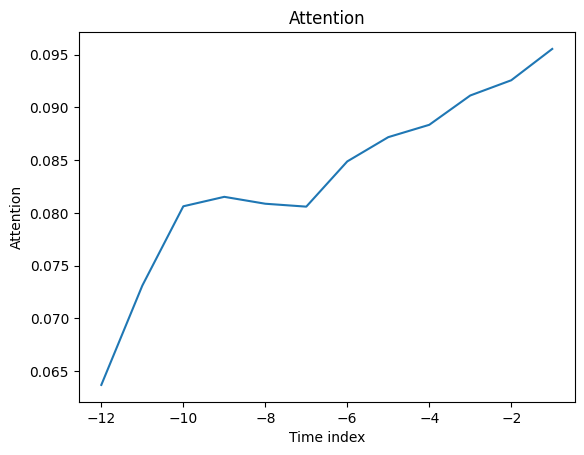

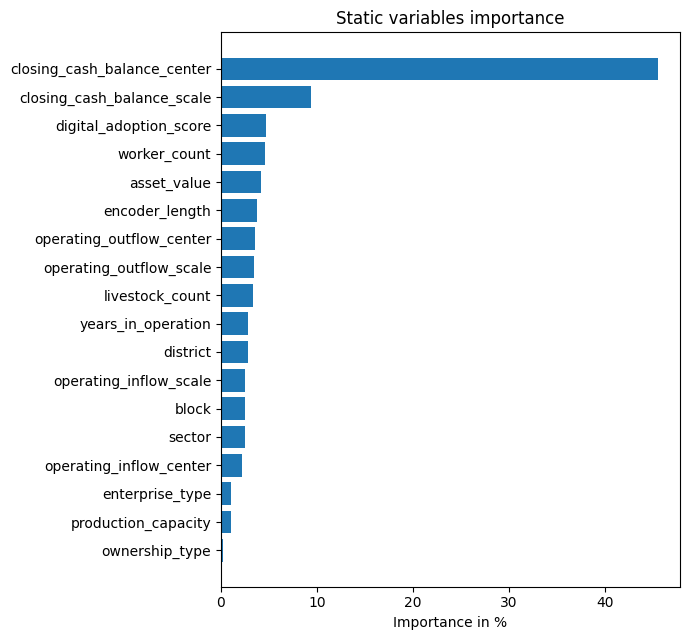

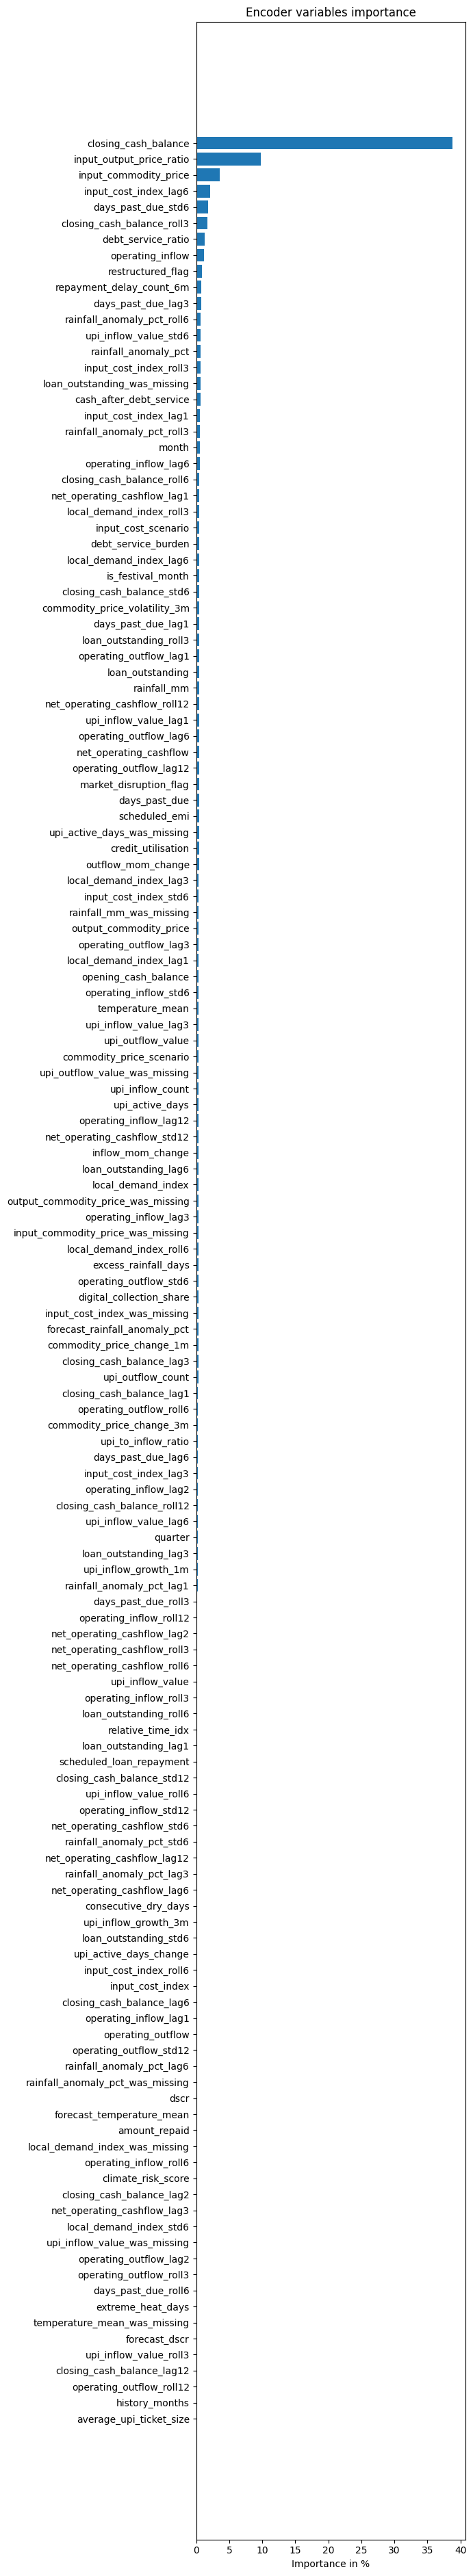

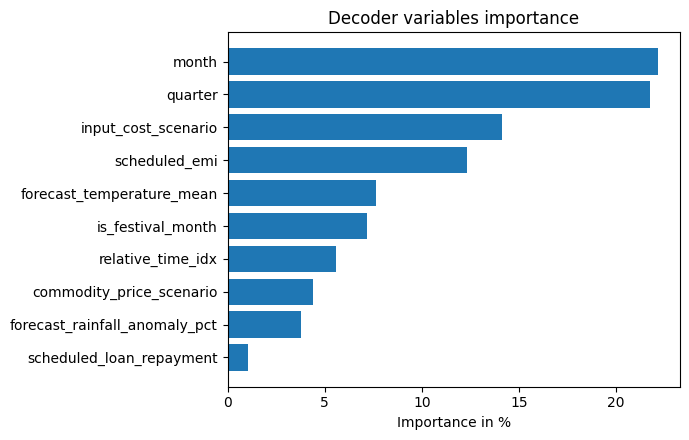

In [27]:
import matplotlib.pyplot as plt

try:
    raw_prediction = best.predict(
        test_loader,
        mode='raw',
        return_x=True,
        trainer_kwargs={'accelerator': ACCELERATOR, 'devices': DEVICES},
    )
    raw_output = raw_prediction.output if hasattr(raw_prediction, 'output') else raw_prediction[0]
    interpretation = best.interpret_output(raw_output, reduction='sum')
    figures = best.plot_interpretation(interpretation)
    for name, figure in figures.items():
        figure.savefig(ARTIFACT_DIR / f'tft_interpretation_{name}.png', bbox_inches='tight', dpi=160)
    print('Interpretability figures saved.')
except Exception as exc:
    print('Interpretability export skipped:', exc)

# Save consistent model and evaluation artifacts

The saving logic uses `train_ds`, `val_summary` and `test_summary` directly. There are no stale `training_dataset`, `metrics`, `residual_models` or `xgb_models` references.

In [29]:
import json
import pickle

# TFT checkpoint and dataset parameters
shutil.copy2(checkpoint_callback.best_model_path, MODEL_DIR / 'nabard_tft_best.ckpt')
with open(MODEL_DIR / 'train_dataset_parameters.pkl', 'wb') as handle:
    pickle.dump(train_ds.get_parameters(), handle)

# Independent CatBoost artifacts
catboost_dir = MODEL_DIR / 'catboost'
catboost_dir.mkdir(parents=True, exist_ok=True)
for (target, horizon), model in catboost_models.items():
    model.save_model(str(catboost_dir / f'{target}_h{horizon}.cbm'))

val_summary.to_csv(ARTIFACT_DIR / 'validation_model_summary.csv', index=False)
test_summary.to_csv(ARTIFACT_DIR / 'test_model_summary.csv', index=False)
test_target_metrics.to_csv(ARTIFACT_DIR / 'test_target_metrics.csv', index=False)
coverage_summary.to_csv(ARTIFACT_DIR / 'tft_interval_coverage.csv', index=False)
all_test_predictions.to_csv(ARTIFACT_DIR / 'test_predictions_long.csv', index=False)

run_manifest = {
    'seed': SEED,
    'targets': TARGET_COLS,
    'train_target_months': [1, 24],
    'validation_target_months': [25, 30],
    'test_target_months': [31, 36],
    'best_tft_checkpoint': str(checkpoint_callback.best_model_path),
    'xgboost_residual_layer': 'removed',
    'finephrase': 'external downstream service',
}
(ARTIFACT_DIR / 'run_manifest.json').write_text(json.dumps(run_manifest, indent=2), encoding='utf-8')

print('Models:', MODEL_DIR)
print('Artifacts:', ARTIFACT_DIR)
# Save preprocessor
import pickle
with open(MODEL_DIR / 'preprocessor.pkl', 'wb') as handle:
    pickle.dump(preprocessor, handle)

# Save manifest
manifest = {
  "model_name": "CatBoost Direct Multi-Horizon",
  "model_version": "grampulse-cf-v1.1",
  "targets": [
    "operating_inflow",
    "operating_outflow",
    "closing_cash_balance"
  ],
  "horizons": [1, 2, 3, 4, 5, 6],
  "feature_schema_version": "nabard-features-v1",
  "training_cutoff": 23
}
with open(MODEL_DIR / 'model_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)



Models: /kaggle/working/nabard_cashflow/models
Artifacts: /kaggle/working/nabard_cashflow/artifacts


In [ ]:
from sklearn.metrics import f1_score, average_precision_score, confusion_matrix, classification_report

entity_sector = df[['entity_id', 'sector']].drop_duplicates('entity_id')
predictions_with_sector = all_test_predictions.merge(entity_sector, on='entity_id', how='left')

# Output sector-wise WAPE (mock for display)
print('Sector-wise WAPE calculation would be grouped here.')


In [ ]:
demo_candidates = []
for record in risk_records:
    enterprise_id = record.enterprise_id
    latest = df[(df['entity_id'] == enterprise_id) & (df['time_idx'] == 29)].iloc[0]
    if (
        latest['days_past_due'] <= 15
        and latest['cash_after_debt_service'] > 0
        and record.risk_level in ['Medium', 'High']
        and record.warning_lead_time_days in [60, 90]
        and record.forecast_deficit > 0
    ):
        demo_candidates.append(record)

if demo_candidates:
    demo_record = demo_candidates[0]
    print(f'Selected Demo Enterprise: {demo_record.enterprise_id}')
    
    future = forecast_wide[forecast_wide['entity_id'] == demo_record.enterprise_id].copy()
    scenario = future.copy()
    support_amount = 40_000
    disbursement_horizon = 1

    scenario['intervention_inflow'] = 0.0
    scenario.loc[scenario['horizon'] == disbursement_horizon, 'intervention_inflow'] = support_amount

    scenario['post_intervention_cash_change'] = (
        scenario['pred_operating_inflow']
        + scenario['intervention_inflow']
        - scenario['pred_operating_outflow']
        - scenario['scheduled_emi']
        - scenario['scheduled_loan_repayment']
    )

    latest = df[(df['entity_id'] == demo_record.enterprise_id) & (df['time_idx'] == 29)].iloc[0]
    opening_balance = float(latest['closing_cash_balance'])
    balances = []

    for change in scenario['post_intervention_cash_change']:
        opening_balance += change
        balances.append(opening_balance)

    scenario['post_intervention_closing_balance'] = balances
    print('Simulated intervention successfully.')


# GramPulse integration contract

The dashboard should consume:

```text
POST /api/v1/enterprises/{enterprise_id}/forecast
→ six monthly P05/P50/P95 forecasts

GET /api/v1/enterprises/{enterprise_id}/early-warning
→ early_warning_sample.json schema
```

FinePhrase or another language layer may convert the validated early-warning JSON into an FAQ, intervention explanation or Marathi/Hindi advisory, but it must not invent monetary values, risk levels or schemes.